<a href="https://colab.research.google.com/github/biancarosa03/APC-1---/blob/main/CN_APLICADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ANÁLISE 1 - DIFERENTES NÚMEROS DE STOKES

St = 0.1
Erro máximo = 3.332411e-07
RMSE        = 4.524679e-08

St = 1.0
Erro máximo = 3.091305e-11
RMSE        = 1.327291e-11

St = 5.0
Erro máximo = 4.474199e-14
RMSE        = 3.761416e-14


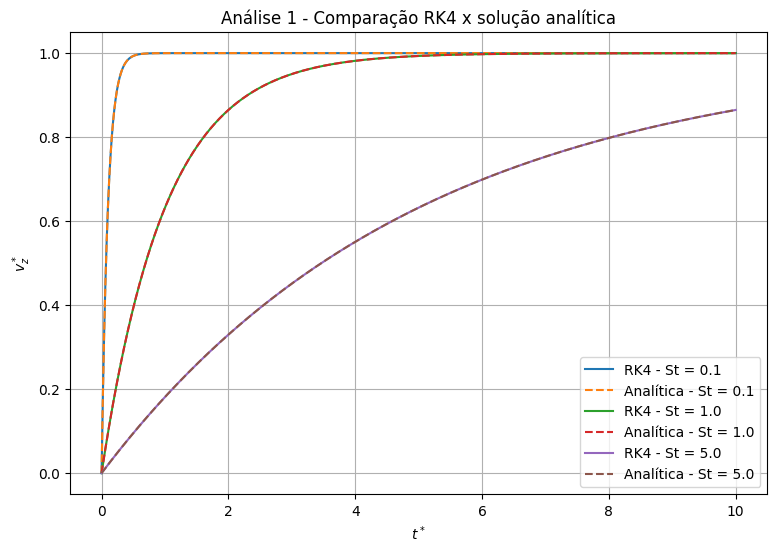



ANÁLISE 2 - INFLUÊNCIA DO PASSO DE TEMPO

h = 0.5
Erro máximo = 2.914030e-04
RMSE        = 1.220149e-04

h = 0.2
Erro máximo = 5.796954e-06
RMSE        = 2.443017e-06

h = 0.1
Erro máximo = 3.332411e-07
RMSE        = 1.418148e-07

h = 0.05
Erro máximo = 1.997610e-08
RMSE        = 8.564301e-09

h = 0.01
Erro máximo = 3.091305e-11
RMSE        = 1.327291e-11


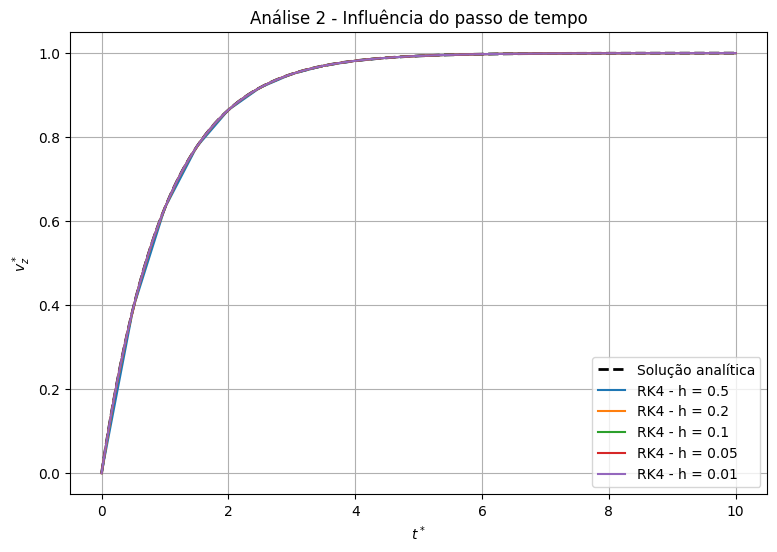



ANÁLISE 3 - EFEITO INERCIAL
St = 1.0
Re_s = 0.5
h = 0.01
Erro máximo = 5.775092e-11
RMSE        = 2.287144e-11


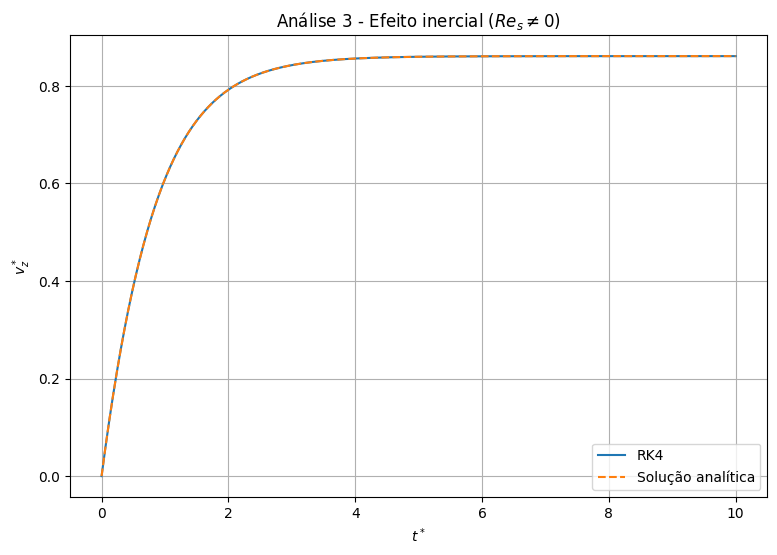



ANÁLISE 4 - VALIDAÇÃO DA SOLUÇÃO NUMÉRICA

Re_s       Erro máximo          RMSE                
--------------------------------------------------
0.1        3.580802e-11         1.510804e-11        
0.5        5.775092e-11         2.287144e-11        
1.0        8.989498e-11         3.337503e-11        


ANÁLISE 5 - VARIAÇÃO DO NÚMERO DE REYNOLDS


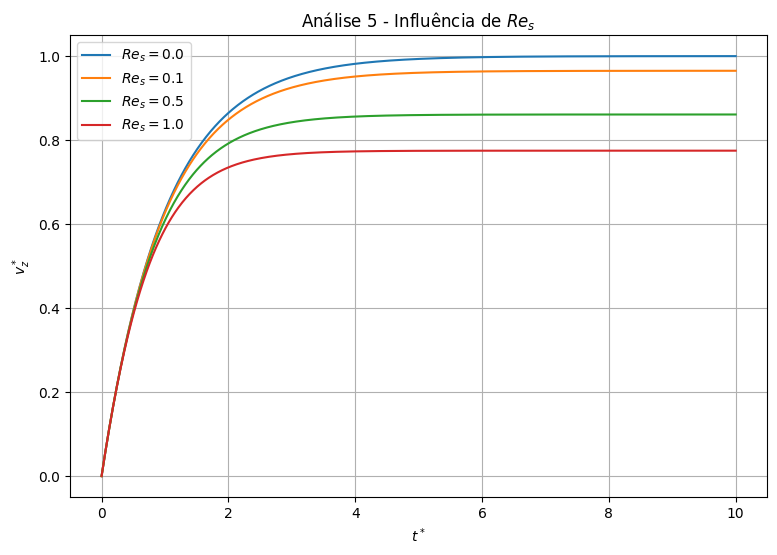



VELOCIDADE TERMINAL ADIMENSIONAL
Re_s = 0.0   -> v_terminal* = 1.000000
Re_s = 0.1   -> v_terminal* = 0.965074
Re_s = 0.5   -> v_terminal* = 0.861002
Re_s = 1.0   -> v_terminal* = 0.774852


In [ ]:
import math
import matplotlib.pyplot as plt

# Da APC temos definido o seguinte:
# St * dv*/dt* = 1 - v* - (3/8)*Re_s*(v*)^2
# Que isolando a derivada fica commo: dv*/dt* = [1 - v* - (3/8)*Re_s*(v*)^2] / St

# 1. EQ. DIF. ADIMENSIONAL

def f(t, v, St, Re_s):  #Função da eq.ad.
    """Parâmetros:
        t    : tempo adimensional
        v    : velocidade adimensional
        St   : número de Stokes
        Re_s : número de Reynolds da partícula
    """
    return (1 - v - (3/8) * Re_s * v**2) / St

# 2. MÉTODO DE RUNGE-KUTTA DE QUARTA ORDEM

def rk4(St, Re_s, h, t0, tf, v0):
    # Listas para armazenar os resultados
    tempos = [t0]
    velocidades = [v0]
    t = t0
    v = v0

    while t < tf: # Continua até atingir o tempo final

        passo = min(h, tf - t)
        k1 = f(t, v, St, Re_s)  # Cálculo de k1
        k2 = f(t=t + passo/2, v=v + k1*passo/2, St=St, Re_s=Re_s)         # Cálculo de k2
        k3 = f(t + passo/2, v + k2*passo/2, St, Re_s)  # Cálculo de k3
        k4 = f(t + passo, v + k3*passo, St, Re_s)  # Cálculo de k4

        v = v + (passo/6) * (k1 + 2*k2 + 2*k3 + k4)  # Atualização da velocidade

        t = t + passo         # Atualização do tempo

        # Armazenamento dos resultados
        tempos.append(t)
        velocidades.append(v)

    return tempos, velocidades

# 3. SOLUÇÃO ANALÍTICA PARA Re_s -> 0

# Quando Re_s = 0: St * dv*/dt* = 1 - v*
# Com v*(0) = 0: v*(t*) = 1 - exp(-t*/St)

def solucao_analitica_Re0(t, St):
    """ Solução analítica para o caso Re_s = 0."""

    return 1 - math.exp(-t / St)

# 4. SOLUÇÃO ANALÍTICA PARA Re_s != 0
# Para Re_s != 0, a equação: St * dv*/dt* = 1 - v* - (3/8)Re_s(v*)^2 é uma equação de Riccati.

def solucao_analitica_Re(t, St, Re_s):
    """Solução analítica para Re_s != 0. Baseada na solução de Riccati apresentada no roteiro."""

    if abs(Re_s) < 1e-14:      # Caso limite Re_s = 0
        return solucao_analitica_Re0(t, St)

    s = math.sqrt(1 + (3/2) * Re_s)

    # Velocidade terminal adimensional

    # Forma numericamente mais estável de: (-1 + sqrt(1 + 3/2 Re_s)) / (3/4 Re_s)
    v_terminal = 2 / (s + 1)
    Q = (3 * Re_s) / (8 * St)     # Coeficientes da solução analítica

    P = (-(3 * Re_s * v_terminal) / (4 * St) - 1 / St)

    # Expressão da solução
    denominador = (Q / P + (-1 / v_terminal - Q / P) * math.exp(-P * t))

    return v_terminal + 1 / denominador

# 5. FUNÇÕES PARA ANÁLISE DOS ERROS

def erro_maximo(numerico, analitico):
    """Calcula o erro absoluto máximo."""

    erros = []

    for i in range(len(numerico)):
        erro = abs(numerico[i] - analitico[i])
        erros.append(erro)

    return max(erros)

def erro_medio_quadratico(numerico, analitico):
    """Calcula o erro quadrático médio (RMSE)."""

    soma = 0

    for i in range(len(numerico)):
        soma += (numerico[i] - analitico[i])**2

    return math.sqrt(soma / len(numerico))

# ANÁLISE 1 - Comparação entre RK4 e solução analítica para diferentes valores de St.
# Re_s -> 0
print("=" * 60)
print("ANÁLISE 1 - DIFERENTES NÚMEROS DE STOKES")
print("=" * 60)

# Parâmetros
Re_s = 0.0
h = 0.01
t0 = 0.0
tf = 10.0
v0 = 0.0

valores_St = [0.1, 1.0, 5.0]

plt.figure(figsize=(9, 6))

for St in valores_St:

    t, v_num = rk4(St, Re_s, h, t0, tf, v0) # Solução numérica

    # Solução analítica
    v_an = []

    for tempo in t:
        v_an.append(solucao_analitica_Re0(tempo, St))

    # Gráfico
    plt.plot(t, v_num, label=f'RK4 - St = {St}')
    plt.plot(t, v_an, '--', label=f'Analítica - St = {St}'  )

    # Erros
    erro_max = erro_maximo(v_num, v_an)
    rmse = erro_medio_quadratico(v_num, v_an)

    print(f"\nSt = {St}")
    print(f"Erro máximo = {erro_max:.6e}")
    print(f"RMSE        = {rmse:.6e}")

plt.xlabel(r'$t^*$')
plt.ylabel(r'$v_z^*$')
plt.title('Análise 1 - Comparação RK4 x solução analítica')
plt.grid(True)
plt.legend()
plt.show()


# ANÁLISE 2 - Influência do passo de tempo h

print("\n")
print("=" * 60)
print("ANÁLISE 2 - INFLUÊNCIA DO PASSO DE TEMPO")
print("=" * 60)

# Cenário fixo
St = 1.0
Re_s = 0.0
t0 = 0.0
tf = 10.0
v0 = 0.0

# Diferentes passos
valores_h = [0.5, 0.2, 0.1, 0.05, 0.01]

plt.figure(figsize=(9, 6))

t_an = [] # Solução analítica para comparação

# Tempos criados utilizando o menor passo
t_an, _ = rk4(St,Re_s,min(valores_h),t0,tf,v0)

v_an = []

for tempo in t_an:
    v_an.append(solucao_analitica_Re0(tempo, St))

plt.plot(t_an,v_an,'k--',linewidth=2,label='Solução analítica')

for h in valores_h:
    t, v_num = rk4(St,Re_s,h,t0,tf,v0)

    # Solução analítica nos mesmos pontos
    v_exata = []

    for tempo in t:
        v_exata.append(solucao_analitica_Re0(tempo, St))

    erro_max = erro_maximo(v_num, v_exata)
    rmse = erro_medio_quadratico(v_num, v_exata)

    print(f"\nh = {h}")
    print(f"Erro máximo = {erro_max:.6e}")
    print(f"RMSE        = {rmse:.6e}")

    plt.plot(t,v_num,label=f'RK4 - h = {h}')


plt.xlabel(r'$t^*$')
plt.ylabel(r'$v_z^*$')
plt.title('Análise 2 - Influência do passo de tempo')
plt.grid(True)
plt.legend()
plt.show()

# ANÁLISE 3 - Caso com efeito inercial: Re_s != 0

print("\n")
print("=" * 60)
print("ANÁLISE 3 - EFEITO INERCIAL")
print("=" * 60)

# Parâmetros
St = 1.0
Re_s = 0.5
h = 0.01
t0 = 0.0
tf = 10.0
v0 = 0.0

# Solução numérica
t, v_num = rk4(St,Re_s,h,t0,tf,v0)

# Solução analítica
v_an = []

for tempo in t:
    v_an.append(solucao_analitica_Re(tempo,St,Re_s))

# Erros
erro_max = erro_maximo(v_num, v_an)
rmse = erro_medio_quadratico(v_num, v_an)

print(f"St = {St}")
print(f"Re_s = {Re_s}")
print(f"h = {h}")
print(f"Erro máximo = {erro_max:.6e}")
print(f"RMSE        = {rmse:.6e}")

plt.figure(figsize=(9, 6)) # Gráfico

plt.plot(t,v_num,label='RK4')

plt.plot(t,v_an,'--',label='Solução analítica')

plt.xlabel(r'$t^*$')
plt.ylabel(r'$v_z^*$')
plt.title(r'Análise 3 - Efeito inercial ($Re_s \neq 0$)')
plt.grid(True)
plt.legend()
plt.show()

# ANÁLISE 4 - Validação para diferentes valores de Re_s

print("\n")
print("=" * 60)
print("ANÁLISE 4 - VALIDAÇÃO DA SOLUÇÃO NUMÉRICA")
print("=" * 60)

St = 1.0
h = 0.01
t0 = 0.0
tf = 10.0
v0 = 0.0

valores_Re = [0.1, 0.5, 1.0]

print("\n{:<10} {:<20} {:<20}".format("Re_s","Erro máximo","RMSE"))

print("-" * 50)

for Re_s in valores_Re:
    t, v_num = rk4(St,Re_s,h,t0,tf,v0) # RK4

    # Analítica
    v_an = []
    for tempo in t:
        v_an.append(solucao_analitica_Re(tempo, St, Re_s))

    # Erros
    erro_max = erro_maximo(v_num, v_an)
    rmse = erro_medio_quadratico(v_num, v_an)

    print(
        "{:<10} {:<20.6e} {:<20.6e}".format( Re_s,erro_max, rmse))

# ANÁLISE 5 - Comportamento da solução para diferentes Re_s

print("\n")
print("=" * 60)
print("ANÁLISE 5 - VARIAÇÃO DO NÚMERO DE REYNOLDS")
print("=" * 60)

St = 1.0
h = 0.01
t0 = 0.0
tf = 10.0
v0 = 0.0

# Incluímos Re_s = 0 para visualizar o limite assintótico
valores_Re = [0.0, 0.1, 0.5, 1.0]
plt.figure(figsize=(9, 6))

for Re_s in valores_Re:
    t, v_num = rk4(St, Re_s, h, t0, tf, v0)     # Solução numérica
    plt.plot(t, v_num, label=f'$Re_s = {Re_s}$')   # Gráfico

plt.xlabel(r'$t^*$')
plt.ylabel(r'$v_z^*$')
plt.title(r'Análise 5 - Influência de $Re_s$')
plt.grid(True)
plt.legend()
plt.show()

# COMPARAÇÃO DAS VELOCIDADES TERMINAIS

print("\n")
print("=" * 60)
print("VELOCIDADE TERMINAL ADIMENSIONAL")
print("=" * 60)

for Re_s in valores_Re:
    if Re_s == 0:
        v_terminal = 1.0
    else:
        s = math.sqrt(1 + (3/2) * Re_s)
        v_terminal = 2 / (s + 1)

    print(
        f"Re_s = {Re_s:<5} -> "
        f"v_terminal* = {v_terminal:.6f}")